In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import quad

from tracklab import ExperimentReader
from icl import generate_icl_batch

from configurations import create_fig, set_font_sizes, apply_general_styles, save_fig

apply_general_styles()
set_font_sizes('tight')

# Test the empirical probability of induction at a give position in the sequence

In [2]:
def P_ind_per_position(V,L,rho,num_samples=30000):
    B = num_samples  # number of sequences in the batch
    K = int(rho * V)  # number of triggers per sequence

    batch = generate_icl_batch(num_samples=B, V=V, L=L, K=K)

    input = batch["sequence"][:, :-1]  # shape (B, L)
    is_trigg = batch["is_trigg"]  # shape (B, L)
    counts = batch["counts"]  # shape (B, L)

    # Mask for positions where induction is possible (is_trigg == 1 and counts > 1)
    ind_possible = (is_trigg == 1) & (counts > 1) # shape (B, L)

    return ind_possible.float().mean(dim=0).numpy()  # shape (L,)

def P_ind_theory(V,L,rho):
    ls = np.arange(L)
    cte = rho/(1 + rho)
    return cte * (1 - np.exp(-ls/(V*(1+rho))))

In [3]:
Vs = [50,100,150,200]
# V = 50
L = 100
rho = 0.5 
# rhos = [0.1, 0.2]
res = {}
# for rho in rhos:
for V in Vs:
    # res[rho] = P_ind_per_position(V, L, rho)
    res[V] = P_ind_per_position(V, L, rho)

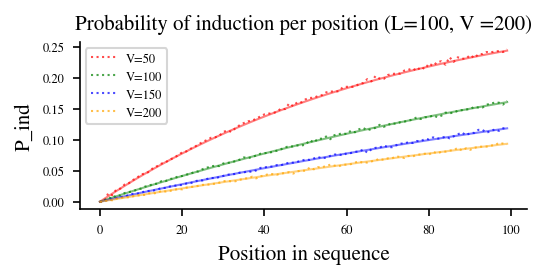

In [67]:
fig , axes = create_fig()
colors = ['r', 'g', 'b', 'orange', 'purple', 'brown', 'pink', 'gray']
ax = axes
# for rho in rhos:
for V in Vs:
    # P_ind = res[rho]
    # ax.plot(P_ind, label=f'rho={rho}',alpha=0.7,ls=':')
    # ax.axhline(rho/(1+rho),ls='--',color='black',alpha=0.5)
    P_ind = res[V]
    idx = Vs.index(V)
    ax.plot(P_ind, label=f'V={V}',alpha=0.7,ls=':',color=colors[idx])
    ax.plot(P_ind_theory(V,L,rho),ls='-',alpha=0.5,color=colors[idx])
ax.set_xlabel('Position in sequence')
ax.set_ylabel('P_ind')
ax.set_title(f'Probability of induction per position (L={L}, V ={V})')
ax.legend()


In [13]:
def av_Pind(V,L,rho):
    P_ind = P_ind_theory(V,L,rho)# shape (L,)
    av = np.cumsum(P_ind) / np.arange(1,L+1)
    return av

def av_Pind_theory(V,L,rho):
    ls = np.arange(1,L+1)
    m = ls/((1+rho)*V)
    cte = rho/(1 + rho)
    return (cte/m) * (m-1 + np.exp(-m))
    

Computing for rho=0.1
Computing for rho=0.5


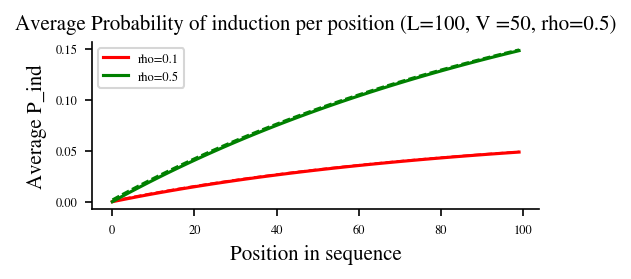

In [22]:
V = 50
L = 100
rhos = [0.1, 0.5 ]
colors = ['r', 'g', 'b', 'orange', 'purple', 'brown', 'pink', 'gray']
fig , axes = create_fig()
ax = axes
for rho in rhos:
    print(f'Computing for rho={rho}')
    av_P_ind = av_Pind(V,L,rho)
    av_P_ind_theory = av_Pind_theory(V,L,rho)
    color=colors[rhos.index(rho)]
    ax.plot(av_P_ind,ls='-',lw=1.5,color=color,label=f'rho={rho}')
    ax.plot(av_P_ind_theory,ls='dashed',lw=1.,color=color)
ax.set_xlabel('Position in sequence')
ax.set_ylabel('Average P_ind')
ax.set_title(f'Average Probability of induction per position (L={L}, V ={V}, rho={rho})')
ax.legend()

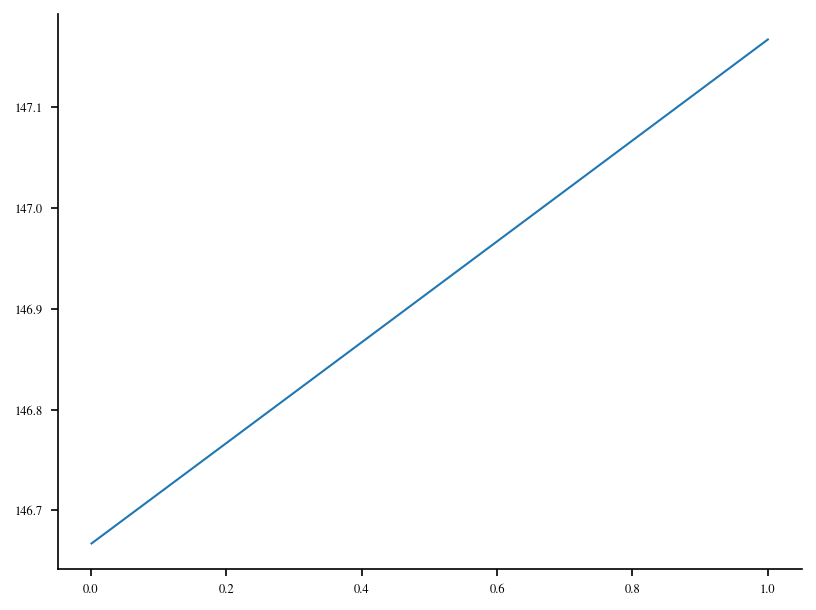

In [3]:
def f(x,m):
    return 1 - np.exp(-m*x)

L = 30
V = 4000
rho = 0.1
m = L/((1+rho)*V)

x = np.linspace(1e-3,1,100)
fval = f(x,m)
plt.plot(x,x/fval,label=f'm={m:.2f}')

# Test new h_star expression

In [2]:
def f(x,m):
    return 1 - np.exp(-m*x)

def integrand(x,*args):
    m = args[0]
    A = args[1]
    V = args[2]
    omega = args[3]
    
    return f(x,m)*np.log( 1 + (V-1) * np.exp(-A*omega*x/f(x,m)) )

def get_on_masks(V,L,K):
    _mask_M_on = np.zeros((L,L))
    _mask_Q_on = np.zeros((V,V))
    _mask_G_on = np.zeros((V,V))
    for i in range(1,L):
        _mask_M_on[i,i-1] = 1
    for i in range(V):
        if i < K:
            _mask_Q_on[i,i] = 1
        else:
            _mask_G_on[i,i] = 1
    return {
        'M': _mask_M_on.astype(bool),
        'Q': _mask_Q_on.astype(bool),
        'G': _mask_G_on.astype(bool)
    }

def evaluate_matrices(masks, matrices):
    results = {}
    for kw in ['M','Q','G']:
        mask = masks[kw]
        mtx = matrices[kw]
        results[kw] = mtx[mask].mean()
    return results


In [123]:
# Instantiate the reader and pick the last run
reader = ExperimentReader('results','../data')

run_id = reader.list_runs()[-1]

# Load configuration
cfg = reader.load_config(run_id)
L , V, d, rho, K , beta , bs  = (cfg['model_args']['seq_len'], 
                                        cfg['model_args']['vocab_size'],
                                        cfg['model_args']['d_model'],
                                        cfg['data_args']['rho'],
                                        cfg['data_args']['K'],
                                        cfg['model_args']['beta'],
                                        cfg['data_args']['batch_size'],
                                        )

eta_0 = cfg['optim_args']['lr']*d/bs

m = L/((1+rho)*V)
A = beta*rho/(1+rho)
av_Pind = (rho/(1+rho))* (m-1+np.exp(-m))/m
limit_loss = (1-av_Pind)*np.log(V) + np.log(1-rho)*rho/(1+rho) * (1-np.exp(-m))/m# (np.log(1-rho))* (rho/(1+rho) - av_Pind)

print(f'Loaded run {run_id} with parameters: L={L}, V={V}, d={d}, rho={rho}, K={K}, beta={beta}, bs={bs}, eta_0={eta_0:.4f}')
print(f' m={m:.4f}, A={A:.4f}, av_Pind={av_Pind:.4f}, limit_loss={limit_loss:.4f}, log V = {np.log(V):.4f}')

# Load metrics and pivot for easier plotting
metrics = reader.load_metrics(run_id)
metrics = metrics.pivot(index='step', columns='metric', values='value').reset_index()

# Load matrices names
list_mtx = reader.list_artifacts(run_id,'matrices')
list_mtx = list_mtx.pivot(index='step',columns='name',values='file').reset_index()
n_prints = len(list_mtx)

Loaded run run_002 with parameters: L=128, V=128, d=256, rho=0.2, K=25, beta=0.25, bs=512, eta_0=5.0000
 m=0.8333, A=0.0417, av_Pind=0.0536, limit_loss=4.5668, log V = 4.8520


In [5]:
# reader.list_artifacts(run_id,'matrices')
reader.list_artifact_groups(run_id)

['logits', 'matrices']

In [4]:
# Compute 'on' order parameters
results = {'M': [], 'Q': [], 'G': [] }

# Loop over the matrices and compute the order parameters
masks = get_on_masks(V,L,K)
for i in range(n_prints):
    row = list_mtx.iloc[i]
    matrices = { kw: reader.load_artifact(run_id,row[kw],'matrices') for kw in ['M','Q','G']}
    res = evaluate_matrices(masks, matrices)
    for kw in ['M','Q','G']:
        results[kw].append(res[kw])

# Create a new dataframe with the results and concatenate it with the metrics dataframe
results_df = pd.DataFrame(results)
new_metrics = pd.concat([metrics,results_df],axis=1)
new_metrics['M'] = new_metrics['M']/np.sqrt(d)
new_metrics['Q'] = new_metrics['Q']/np.sqrt(d)
new_metrics['G'] = new_metrics['G']/np.sqrt(d)
new_metrics['omega'] = new_metrics['M']*new_metrics['Q']*new_metrics['G'] / K

print(new_metrics.columns.tolist())

['step', 'loss', 'top1_accuracy', 'M', 'Q', 'G', 'omega']


In [5]:
L_eff = []
for i in range(n_prints):
    omega = new_metrics.iloc[i]['omega']
    L_eff.append(quad(integrand, 0, 1, args=(m, A, V, omega))[0])

new_metrics['L_eff'] = L_eff    
new_metrics['L_eff'] = rho*new_metrics['L_eff']/(1+rho) + np.log(V) * (1-av_Pind)

Computed av_Pind: 0.0536, limit_loss: 4.5668


Text(0.5, 0.98, 'L=128, V=128, d=256, rho=0.2, K=25, beta=0.25')

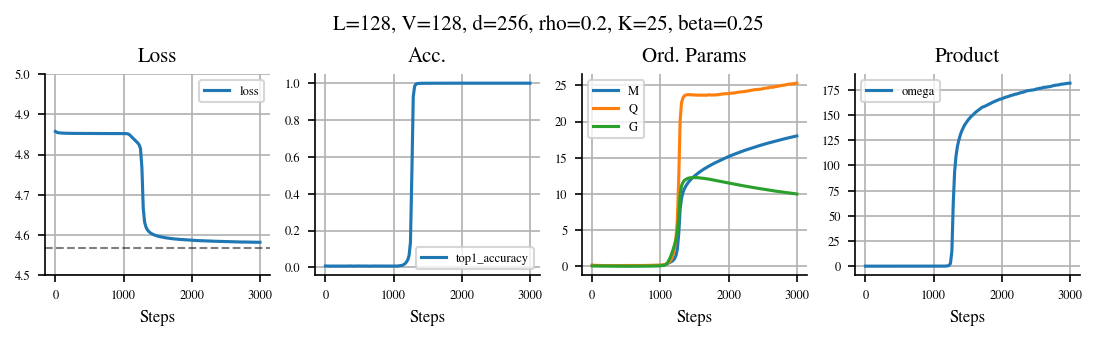

In [6]:
# variables to plot
settings = {
    'Loss': ['loss'],
    'Acc.': ['top1_accuracy'],
    # 'Logits' : ['on_logit_mean'],
    'Ord. Params': ['M','Q','G'],
    'Product': ['omega']  
}

time = new_metrics['step']

fig , axes = create_fig(1,len(settings),size='double',h=0.3,sharex=False)

for i, (title, metrics) in enumerate(settings.items()):
    ax = axes[i]
    ax.grid()
    for metric in metrics:
        x = new_metrics[metric].values
        x = x*np.sign(x[-1])
        ax.plot(time,x, label=metric,lw=1.5)
    ax.set_title(title)
    ax.set_xlabel(r'Steps',fontsize=8)
    ax.legend()


print(f'Computed av_Pind: {av_Pind:.4f}, limit_loss: {limit_loss:.4f}')
axes[0].axhline(1*limit_loss,ls='--',color='black',alpha=0.5)
axes[0].set_ylim(4.5,5)

# ax.set_xlim(0,0.75)
# ax.set_ylim(-1,1)
fig.suptitle(f'L={L}, V={V}, d={d}, rho={rho}, K={K}, beta={beta}')

# plt.show()
# plt.plot((new_metrics['M']/(L-1))**2 - (new_metrics['Q']/K)**2)

In [68]:
order = V**2*np.sqrt(L)
cte = 2/(beta*np.sqrt(rho)*eta_0)

print(f'Computed order parameter: {order:.4f}, cte: {cte:.4f}')


Computed order parameter: 175698.8259, cte: 15928.5816


[55, 63, 70]
Figure saved on /u/c/cerazova/InContextLearning/Manuscript/figures as metrics_summary.png


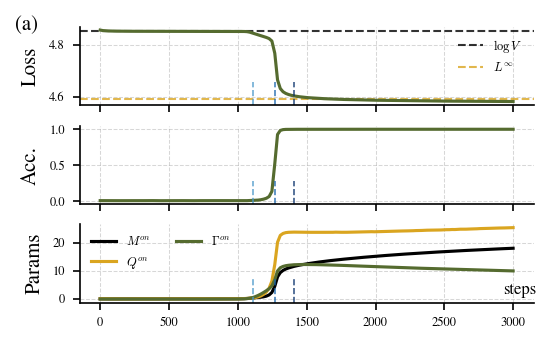

In [ ]:
time_fraction = 0.05
time_middle = 0.42
t_fracs = [time_middle-time_fraction, time_middle, time_middle+time_fraction]
cols = plt.get_cmap('Blues')(np.linspace(0.6,1,len(t_fracs)))
t_idx = [int(frac * len(time)) for frac in t_fracs]
print(t_idx)

fig , axes = create_fig(3,1,w=1.,h=0.6)

ax = axes[0]
ax.axhline(np.log(V),color='black',ls='--',lw=1.,label=r'$\log V$',alpha=0.8)
ax.axhline(np.log(V) * (1-av_Pind),color='goldenrod',ls='--',lw=1.,label=r'$L^\infty$',alpha=0.8)
ax.plot(time,new_metrics['loss'],color='darkolivegreen',lw=1.5)
ax.legend(frameon=False)
ax.set_ylabel('Loss')

ax = axes[1]
ax.plot(time,new_metrics['top1_accuracy'],color='darkolivegreen',lw=1.5)
ax.set_ylabel('Acc.')
# ax.set_xlabel('Steps')

ax = axes[2]
ax.plot(time,new_metrics['M'],label=r'$M^{on}$',color='k',lw=1.5)
ax.plot(time,new_metrics['Q'],label=r'$Q^{on}$',color='goldenrod',lw=1.5)
ax.plot(time,new_metrics['G'],label=r'$\Gamma^{on}$',color='darkolivegreen',lw=1.5)
ax.set_ylabel('Params')
# ax.set_xlabel('Steps')
ax.legend(frameon=False,ncol=2)


for i , idx in enumerate(t_idx):
    t = time[idx]
    c = cols[i]
    for ax in axes:
        ax.axvline(t,ymax=0.3,ls='--',color=c,lw=0.8,alpha=0.8)
        ax.grid(lw=0.5,ls='--',alpha=0.5)
        # ax.set_xlim(0,1030)

fig.text(0.93,0.13,r'steps')

fig.text(0.0,0.97,'(a)',fontsize=10)

save_fig(fig,'metrics_summary',base_dir='../../Manuscript/figures')

In [28]:
matrices = {'M': [], 'Q': [], 'G': []}
for i in t_idx:
    row = list_mtx.iloc[i]
    for kw in ['M','Q','G']: matrices[kw].append(reader.load_artifact(run_id,row[kw],'matrices')/np.sqrt(d))

range = {}
for kw in ['M','Q','G']:
    mtxs = matrices[kw]
    max_val = max([np.abs(mtx).max() for mtx in mtxs])
    range[kw] = max_val

Figure saved on /u/c/cerazova/InContextLearning/Manuscript/figures as matrices.png


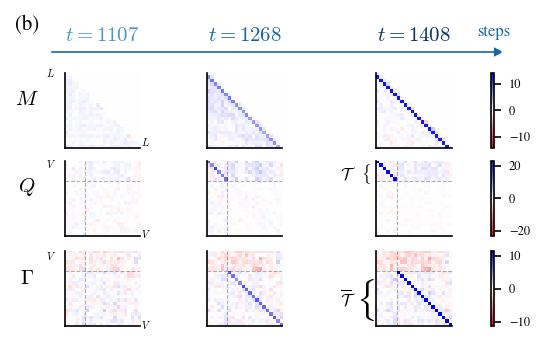

In [29]:
# labels = 
n_tot = 22
n_left = int(n_tot * rho) + 2
n_right = n_tot - n_left
fig , axes = create_fig(3,len(t_fracs),w=1,h=0.6,sharex=False)
# plt.rcParams.update({'text.usetex': False})


for i, idx in enumerate(t_idx):
    for j, kw in enumerate(['M','Q','G']):
        ax = axes[j,i]
        # ax.set_axis_off()
        ax.set_yticks([])
        ax.set_xticks([])
        # ax.spines[['bottom','left']].set_visible(False)
        mtx = matrices[kw][i][K-n_left:K+n_right,K-n_left:K+n_right]
        r = range[kw]*0.9
        if kw == 'M': #filter out the upper diagonal part of the matrix
            mtx = np.tril(mtx)
        im = ax.imshow(mtx, cmap='bwr_r', aspect=1,vmin=-r, vmax=r)
        if j == 0 : ax.set_title(rf'$t={time[idx]}$',color=cols[i],pad=15)
        if i == 0 : ax.set_ylabel(rf'$\Gamma$' if kw == 'G' else rf"${kw}$",rotation=0,labelpad=18)
        if i == 2 : fig.colorbar(im, ax=ax, fraction=0.04, pad=0.3)
        if kw != 'M':
            ax.axhline(n_left-0.5,color='black',ls='--',lw=0.5,alpha=0.3)
            ax.axvline(n_left-0.5,color='black',ls='--',lw=0.5,alpha=0.3)


l , b , w , h = 0.07, 0.9, 0.85, 0.001
rect = l, b, w, h
ax_time = fig.add_axes(rect,zorder=-1)
ax_time.spines['left'].set_visible(False)
ax_time.set_xticks([])
ax_time.set_yticks([])
ax_time.plot(1, 0, ">", transform=ax_time.get_yaxis_transform(), clip_on=False,color=cols[-2],markersize=3)
#set spines color for x axis bottom
ax_time.spines['bottom'].set_color(cols[-2])

# Texts
fig.text(0.88,0.95,r'steps',color=cols[-2])

for i , kw in enumerate(['G','Q','M']):
    fig.text(0.24,0.02 + i*0.29,r'$L$' if kw == "M" else r'$V$',fontsize=5)
    fig.text(0.06,0.24 + i*0.29,r'$L$' if kw == "M" else r'$V$',fontsize=5)


fig.text(0.62,0.49,r'$\mathcal{T}\;\;\; \{$')
# fig.text(0.63,0.1,r'$\mathcal{T}\;\; \{$')
fig.text(0.62, 0.09, r'$\overline{\mathcal{T}}$')
fig.text(0.65, 0.07, r'$\{$',size=17)
# fig.text(0.63, 0.09, /)
# Taller brace
# Creates a 3-line tall brace
# A clean, 3-line tall curly brace that works natively in Matplotlib
# fig.text(0.63, 0.1, r'$\mathcal{T} \left\{ \frac{\binom{\quad}{\quad}}{\quad} \right.$')

fig.text(0.0,0.97,'(b)',fontsize=10)
save_fig(fig,'matrices',base_dir='../../Manuscript/figures')


In [124]:
# Load matrices names
# reader.list_artifact_groups(run_id)
list_logits = reader.list_artifacts(run_id,'logits')

on_logits = []
off_logits = []
all_logits = []
for filename in list_logits['file'].values:
    on_logits.append(reader.load_artifact(run_id,filename,'logits')['on'])
    off_logits.append(reader.load_artifact(run_id,filename,'logits')['off'])
    all_logits.append(reader.load_artifact(run_id,filename,'logits')['all'])
# #replace nans to zeros
# logits = np.nan_to_num(logits, nan=0.0)
# print(f'Loaded {len(logits)} logits with shape {logits.shape}')

mus = [L,int(0.5*L)]
on_logit_mean = {mu: [] for mu in mus}
off_logit_mean = {mu: [] for mu in mus}

for l_on, l_off in zip(on_logits, off_logits):
    for mu in mus:
        on_logit_mean[mu].append(l_on[mu-1].mean())
        off_logit_mean[mu].append(l_off[mu-1].mean())

# off_logit_mean = []
# for l_off in off_logits:
#     off_logit_mean.append(l_off.mean())

complete_logits = []

for idx in t_idx:
    complete_logits.append({'on':[],'off':[]})
    for mu in mus:
        complete_logits[-1]['on'].append(on_logits[idx][mu-1].flatten())
        complete_logits[-1]['off'].append(off_logits[idx][mu-1].flatten())

full_logits = []

for idx in t_idx:
    
    full_logits.append(all_logits[idx][-1])
    print(full_logits[-1].shape)


max_indexes = full_logits[-1][:,:100].max(axis=1).argsort()[-20:]
print(f'Max indexes: {max_indexes}')



(402, 128)
(402, 128)
(402, 128)
Max indexes: [369 401 346 316 150  16 395 264 296   9 255 382 247 215 196 254 111 168
  74 127]


Figure saved on /u/c/cerazova/InContextLearning/Manuscript/figures as logits_evolution.png


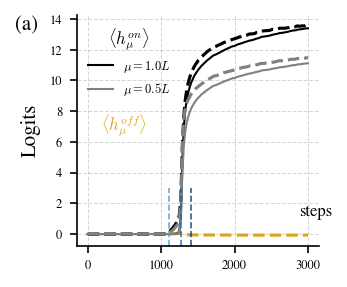

In [36]:
cols = ['black','gray']
fig , axes = create_fig(h=0.25,w=0.3,size='double')

ax = axes

ax.plot(time,off_logit_mean[L],color='goldenrod',lw=1.5,ls='--')
# ax.plot(time,time*0,color='goldenrod',lw=1.0)
for i, mu in enumerate(mus):
    cte = A * (mu/L) / (1-np.exp(-m*mu/L))
    h_on_theory = cte* new_metrics['omega'] 
    ax.plot(time,on_logit_mean[mu],color=cols[i],lw=1.5,ls='--')
    ax.plot(time,h_on_theory,color=cols[i],lw=1.0,label=rf'$\mu={mu/L :.1f}L$')


# ax.axhline(0,color='goldenrod',lw=1.0)
ax.text(0.1,0.5,r'$\langle h^{off}_\mu \rangle$',transform=ax.transAxes,fontsize=8,color='goldenrod')
# ax.set_xlabel('Steps')
ax.set_ylabel(r'Logits')
ax.legend(title=r'$\langle h^{on}_\mu \rangle$',frameon=False,loc='upper left')
ax.text(0.92,0.13,r'steps',transform=ax.transAxes,fontsize=8)


cols = plt.get_cmap('Blues')(np.linspace(0.6,1,len(t_fracs)))
for i , idx in enumerate(t_idx):
    t = time[idx]
    c = cols[i]
    ax.axvline(t,ymax=0.25,ls='--',color=c,lw=0.8,alpha=0.8)
    ax.grid(lw=0.5,ls='--',alpha=0.5)

fig.text(0.0,0.92,'(a)',fontsize=10)
save_fig(fig,'logits_evolution',base_dir='../../Manuscript/figures')

Text(0.0, 0.92, '(b)')

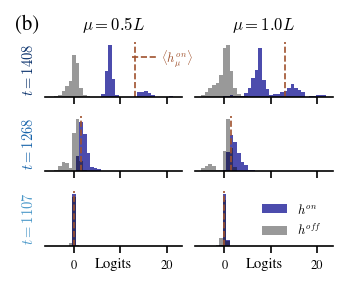

In [ ]:
fig , axes = create_fig(nrows=3,ncols=2,h=0.25,w=0.3,size='double')

for i , idx in enumerate(t_idx):
    for j, mu in enumerate(mus):
        ax = axes[2-i,1-j]
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_xticks([0,10,20],[0,None,20])
        if j == 1: ax.set_ylabel(rf'$t={time[idx]}$',color=cols[i],fontsize=7)
        if i == 2: ax.set_title(rf'$\mu={mu/L :.1f}L$',fontsize=8)
        if i == 0: ax.set_xlabel(r'Logits',fontsize=7,labelpad=-7)
        l_on = complete_logits[i]['on'][j]
        l_off = complete_logits[i]['off'][j]
        ax.hist(l_on,bins=35,alpha=0.7,color='darkblue',label=r'$h^{on}$',density=True,range=(-5,22))
        ax.hist(l_off,bins=35,alpha=0.4,color='black',label=r'$h^{off}$',density=True,range=(-5,22))
        

        omega = new_metrics.iloc[idx]['omega']
        # cte = A * (mu/L) / (1-np.exp(-m*mu/L))
        cte = beta*K/L
        h_on_theory = cte* omega* 2
        ax.axvline(h_on_theory,color='sienna',ls='--',lw=0.8,alpha=1,label=' ')
        if i ==0 and j==0 :
            # Here plot just the first 2 legends for h^on and h^off
            # extract the handles and labels from the ax
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[:2], labels[:2],frameon=False,fontsize=6)
        if i ==2 and j==1 :
            # Here plot just the first 2 legends for h^on and h^off
            # extract the handles and labels from the ax
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[2:], labels[2:],frameon=False,fontsize=6,loc=(0.6,0.5))


fig.text(0.45,0.8,r'$\langle h^{on}_\mu \rangle$',fontsize=6,color='sienna')
fig.text(0.0,0.92,'(b)',fontsize=10)
# save_fig(fig,'logits_distributions',base_dir='../../Manuscript/figures')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Figure saved on /u/c/cerazova/InContextLearning/Manuscript/figures as logits_matrix.png


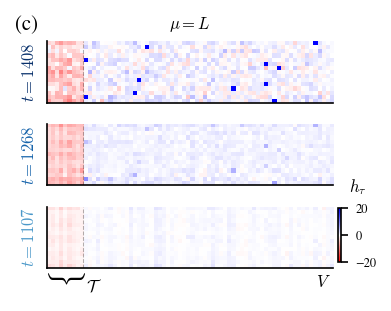

In [79]:
n_tot = 70
n_left = int(n_tot * rho) - 5
n_right = n_tot - n_left

fig , axes = create_fig(nrows=3,h=0.25,w=0.3,size='double')
rnd_indexes = [0,1,2,3,4,5,6,7,8,9]
print(rnd_indexes)
for i , ax in enumerate(axes[::-1]):
    if i == 2: ax.set_title(rf'$\mu=L$',fontsize=8)
    idx = t_idx[i]
    # ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(rf'$t={time[idx]}$',color=cols[i],fontsize=8)
    full_l = full_logits[i][:,K-n_left:K+n_right]
    
    full_l = full_l[max_indexes[5:20]]
    if i == 0: 
        ax.imshow(full_l, cmap='bwr_r', aspect=1,vmin=-9, vmax=9)
    else:
        im = ax.imshow(full_l, cmap='bwr_r', aspect=1,vmin=-20, vmax=20)
    
    ax.axvline(n_left-0.6,color='black',ls='--',lw=0.5,alpha=0.3)
    
    # ax.set_xlim(0,n_tot)
    

# Create new axes for the colorbar
l , b , w , h = 0.996, 0.06, 0.01, 0.2
rect = l, b, w, h   

ax_new = fig.add_axes(rect,zorder=1)
fig.colorbar(im, cax=ax_new, orientation='vertical')

fig.text(0.1,0.0,r'$\{$',rotation='vertical',fontsize=15)
fig.text(0.22,-0.05,r'$\mathcal{T}$',fontsize=8)
fig.text(0.93,-0.03,r'$V$')
fig.text(1.03,0.32,r'$h_\tau$',fontsize=8)

# ax_new.colorbar(im, cax=ax_new, orientation='horizontal')

fig.text(0.0,0.92,'(c)',fontsize=10)
save_fig(fig,'logits_matrix',base_dir='../../Manuscript/figures')

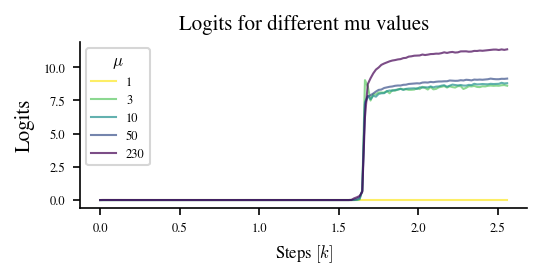

In [9]:
mus = [1,3,10,50,L]

colors = plt.get_cmap('viridis_r')(np.linspace(0,1,len(mus)))
fig , axes = create_fig()
ax = axes
for i,  mu in enumerate(mus):
    log_mu = logits[:,mu-1]
    ax.plot(time,log_mu,label=f'{mu}',alpha=0.7,color=colors[i])

ax.set_title('Logits for different mu values')
ax.set_xlabel(r'Steps $[k]$',fontsize=8)
ax.set_ylabel('Logits')
ax.legend(title=r'$\mu$')

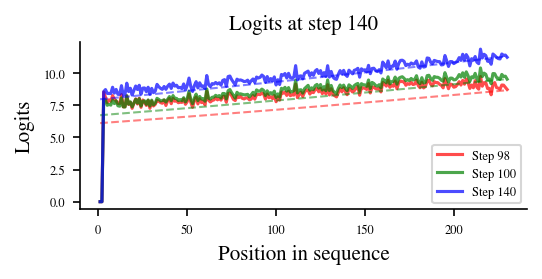

In [15]:
tot_steps = len(logits)
# eval_times = [84,100,tot_steps-1]
eval_times = [98,100,140]
fig , axes = create_fig()
colors = ['r', 'g', 'b', 'orange', 'purple', 'brown', 'pink', 'gray']

mus = np.arange(1,L+1).astype(float)
A = beta * (rho / (1+rho)) * (1/K)
ax = axes
for i , t in enumerate(eval_times):
    log_t = logits[t]
    ax.plot(mus,log_t,label=f'Step {t}',alpha=0.7,color=colors[i],lw=1.5)
    prod = new_metrics['prod'].iloc[t]
    ex = (mus/L) / (1-np.exp(-mus/((1+rho)*V)))
    ax.plot(mus,A*ex*prod,alpha=0.5,color=colors[i],ls='dashed')

    
# 
ax.set_title(f'Logits at step {t}')
ax.set_xlabel('Position in sequence')
ax.set_ylabel('Logits')
ax.legend()

In [7]:
from scipy.stats import binom

def exact_fraction(V, K, L):
    total = 0.0
    for j in range(2, L):          # need at least 1 prior slot
        n_max = min(j-1, L-j)
        if n_max < 1:
            continue
        n_vals = np.arange(1, n_max+1)          # <-- changed from 2
        p_n = binom.pmf(n_vals, j-1, 1.0/V)
        m_max = (L - j) - n_vals
        p_m = binom.cdf(m_max, j-1-n_vals, (K-1)/(V-1))
        total += np.sum(p_n * p_m)
    return (K / (V * L)) * total


import numpy as np

def prob_trigger_no_prior(K, V, mu):
    """
    Exact probability that tau_mu is in the trigger set T (|T|=K, |V|=V)
    AND tau_mu has no prior occurrence in tau_1,...,tau_{mu-1}.
    O(mu) recursion — simple and numerically robust.
    """
    if K <= 0 or K >= V:
        raise ValueError("Require 0 < K < V")
    if mu < 1:
        raise ValueError("mu must be >= 1")

    rho  = K / V
    rho_ = (K - 1) / V  # rho' : P(N -> T'), excluding the fixed trigger t
    pi_t = 1.0 / (V * (1 + rho))

    if mu == 1:
        return K * pi_t  # constraint is vacuous

    x = 1.0 / (1 + rho)      # x_1 = pi(N)
    y = rho_ / (1 + rho)     # y_1 = pi(T')
    for _ in range(mu - 2):
        x, y = (1 - rho) * x + y, rho_ * x

    return K * (x / V)


def prob_trigger_no_prior_closed_form(K, V, mu):
    """O(1) closed form via the two eigenvalues lambda_+/-."""
    if K <= 0 or K >= V:
        raise ValueError("Require 0 < K < V")
    if mu < 1:
        raise ValueError("mu must be >= 1")

    rho  = K / V
    pi_t = 1.0 / (V * (1 + rho))
    if mu == 1:
        return K * pi_t

    x1 = 1.0 / (1 + rho)
    x2 = (1 - 1.0 / V) / (1 + rho)

    disc = (1 + rho) ** 2 - 4.0 / V
    sq = np.sqrt(disc + 0j)
    L = ((1 - rho) + sq) / 2
    l = ((1 - rho) - sq) / 2

    n = mu - 1
    if abs(L - l) < 1e-14:
        return prob_trigger_no_prior(K, V, mu)  # degenerate-root fallback

    x_n = ((x2 - l * x1) * L**(n-1) - (x2 - L * x1) * l**(n-1)) / (L - l)
    return K * (x_n.real / V)

In [8]:
mus = np.arange(1, L + 1)
p_ind_possible_mus = (1-np.array([prob_trigger_no_prior(K, V, mu) for mu in mus])*(1+rho)/rho)*rho/(1+rho)
p_ind_possible_mus_apx = rho/(1+rho) * (1 - np.exp(-mus/((1+rho)*V)))



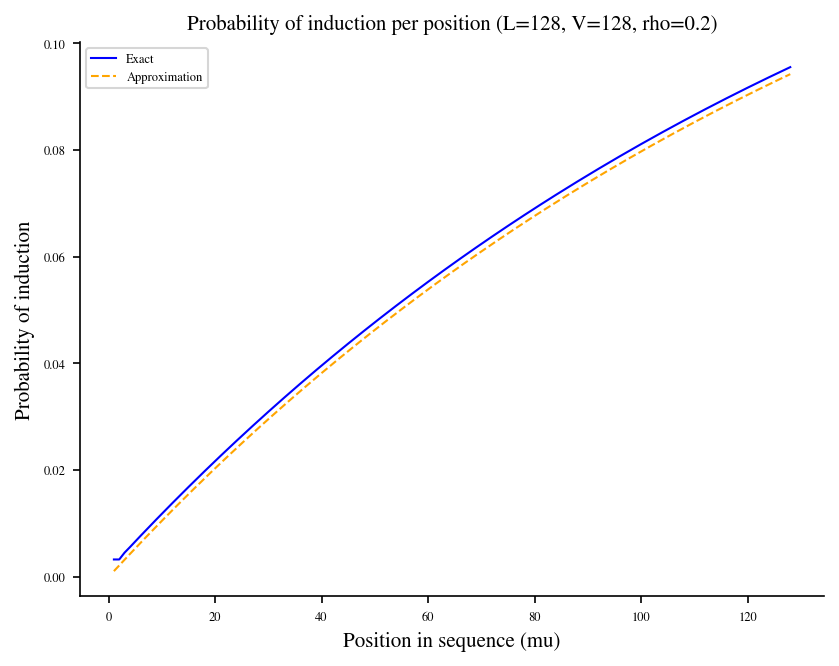

In [9]:
plt.plot(mus, p_ind_possible_mus, label='Exact', color='blue')
plt.plot(mus, p_ind_possible_mus_apx, label='Approximation', color='orange', linestyle='--')
plt.xlabel('Position in sequence (mu)')
plt.ylabel('Probability of induction')
plt.title(f'Probability of induction per position (L={L}, V={V}, rho={rho})')
plt.legend()

In [12]:
L_new = 100
Ls = np.arange(1, L_new+1)

# f_bar_exact = np.array([sum(exact_fraction(V, K, mu) for mu in range(1, l+1))/l for l in Ls])
p_mus = rho/(1+rho) * (1 - np.exp(-Ls/((1+rho)*V)))
f_bar_exact = np.cumsum(p_mus) / Ls

lmbda_values = Ls/((1+rho)*V)
f_bar_approx = rho/(1+rho) * (lmbda_values - 1 + np.exp(-lmbda_values))/lmbda_values

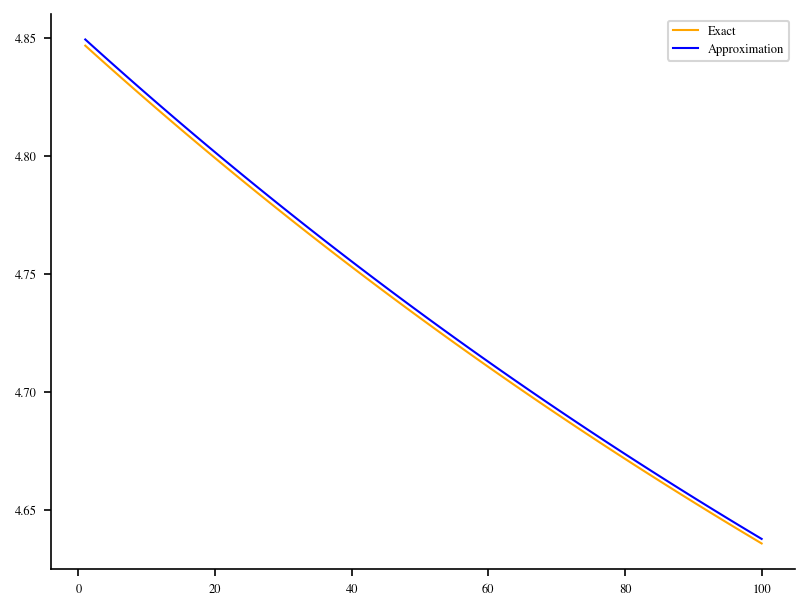

In [13]:
plt.plot(Ls, (1-f_bar_exact)*np.log(V), label='Exact', color='orange')
plt.plot(Ls, (1-f_bar_approx)*np.log(V), label='Approximation', color='blue')
plt.legend()

# ODE

In [2]:
def g(x,lmbda):
    return 1 - np.exp(-lmbda*x)

def integrand_ode(x, lmbda, A, V, omega):
    num = 2*V*x
    denom =  (V-1) +  np.exp(A*omega*x/g(x,lmbda))
    return num/denom


def psi_function(omega,lmbda,A,V):
    return quad(integrand_ode, 0, 1, args=(lmbda, A, V, omega))[0]

def c_lambda(lmbda):
    return quad(lambda x: x**2/g(x,lmbda), 0, 1)[0]

def p_lambda(lmbda):
    return quad(lambda x: x**3/(g(x,lmbda))**2, 0, 1)[0]

def psi_approx1(omega,cte_lambda,A,V):
    return 1 - 2*A*cte_lambda*omega/V

def psi_approx2(omega,cte_lambda,p_lambda,A,V):
    return 1 - 2*A*cte_lambda*omega/V - A**2*p_lambda*omega**2/V


def gradient(q, t, lmbda, A, V, K, L, B):
    M = q[0]
    Q = q[1]
    G = q[2]
    omega = M*Q*G/K
    psi = psi_function(omega,lmbda,A,V)
    common_term = B * psi / K

    tau = V**2*np.sqrt(L)

    dM = common_term * Q * G / L
    dQ = common_term * M * G / K
    dG = common_term * M * Q / (V-K)


    return np.array([dM, dQ, dG]) #*tau

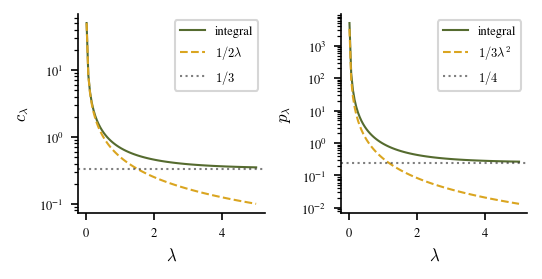

In [130]:
# Simple test of consitency of the approximation
lmbdas = np.linspace(0.01,5,100)
c_ls = [c_lambda(lmbda) for lmbda in lmbdas]
p_ls = [p_lambda(lmbda) for lmbda in lmbdas]

fig , axes = create_fig(ncols=2)


ax = axes[0]
ax.plot(lmbdas,c_ls,ls='-',color='darkolivegreen',label=r'integral')
ax.plot(lmbdas,1/(2*lmbdas),ls='--',color='goldenrod',label=r'$1/2\lambda$')
ax.axhline(1/3,ls=':',color='black',label=r'$1/3$',alpha=0.5)

ax.legend()

ax.set_xlabel(r'$\lambda$',fontsize=8)
ax.set_ylabel(r'$c_\lambda$',fontsize=8)
ax.set_yscale('log')

ax = axes[1]
ax.plot(lmbdas,p_ls,ls='-',color='darkolivegreen',label=r'integral')
ax.plot(lmbdas,1/(3*lmbdas**2),ls='--',color='goldenrod',label=r'$1/3\lambda^2$')
ax.axhline(1/4,ls=':',color='black',label=r'$1/4$',alpha=0.5)

ax.legend()
ax.set_xlabel(r'$\lambda$',fontsize=8)
ax.set_ylabel(r'$p_\lambda$',fontsize=8)
ax.set_yscale('log')

In [201]:
beta , rho , L , V = 0.5 , 0.1 , 10, 1000

lmbda = L/((1+rho)*V)
A = beta * (rho / (1+rho)) 
cte_lambda = c_lambda(lmbda)
pte_lambda = p_lambda(lmbda)

print(f'Computed lmbda: {lmbda:.4f}, A: {A:.4f}, cte_lambda: {cte_lambda:.4f}, pte_lambda: {pte_lambda:.4f}')

Computed lmbda: 0.0091, A: 0.0455, cte_lambda: 55.1669, pte_lambda: 6086.7710


In [202]:
omega_thresh = 3* (1/A) * np.log(V-1) * (1-np.exp(-lmbda))

omegas = np.linspace(0.0,2*omega_thresh,100)

psi_true = [psi(omega,lmbda,A,V) for omega in omegas]
psi_appx1 = [psi_approx1(omega,cte_lambda,A,V) for omega in omegas]
# psi_appx2 = [psi_approx2(omega,cte_lambda,pte_lambda,A,V) for omega in omegas]

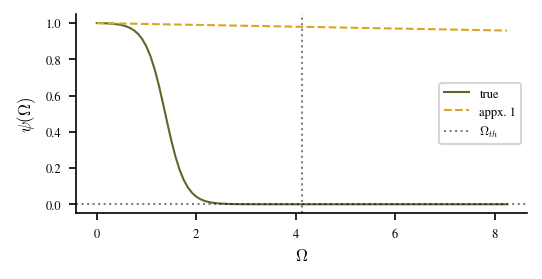

In [203]:
fig , ax = create_fig()


ax.plot(omegas,psi_true,ls='-',color='darkolivegreen',label=r'true')
ax.plot(omegas,psi_appx1,ls='--',color='goldenrod',label=r'appx. 1')
# ax.plot(omegas,psi_appx2,ls=':',color='black',label=r'appx. 2')
ax.axvline(omega_thresh,ls=':',color='black',label=r'$\Omega_{th}$',alpha=0.5)
ax.axhline(0,ls=':',color='black',alpha=0.5)

ax.set_xlabel(r'$\Omega$',fontsize=8)
ax.set_ylabel(r'$\psi(\Omega)$',fontsize=8)
ax.legend()

In [155]:
1/A

22.0

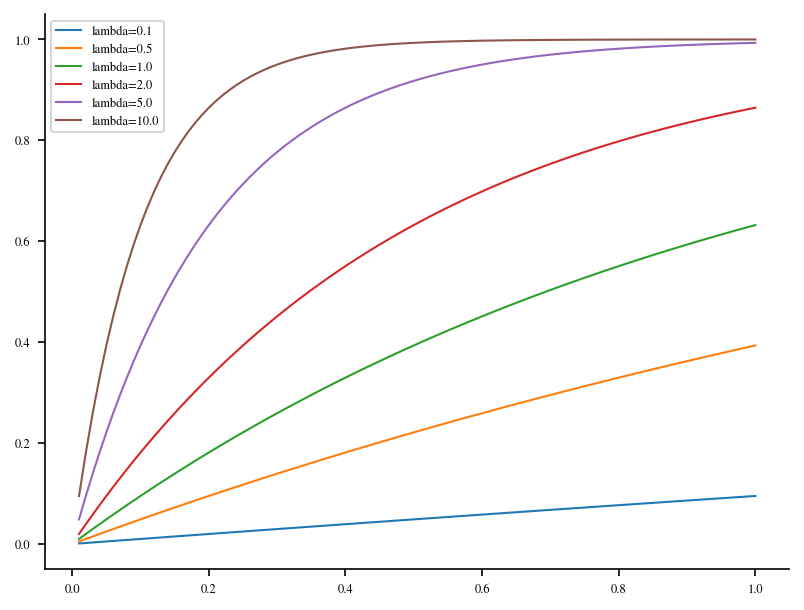

In [141]:
xvals = np.linspace(0.01,1,100)
for lmbda in [0.1, 0.5, 1.0, 2.0,5.0,10.0]:
    yvals = [g(x,lmbda) for x in xvals]
    plt.plot(xvals,yvals,label=f'lambda={lmbda}')
plt.legend()

# Solution ODE

In [121]:
# Instantiate the reader and pick the last run
reader = ExperimentReader('results_test','../data')

run_id = reader.list_runs()[-1]

cfg = reader.load_config(run_id)
L , V, d, rho, K , beta , bs  = (cfg['model_args']['seq_len'], 
                                        cfg['model_args']['vocab_size'],
                                        cfg['model_args']['d_model'],
                                        cfg['data_args']['rho'],
                                        cfg['data_args']['K'],
                                        cfg['model_args']['beta'],
                                        cfg['data_args']['batch_size'],
                                        )

eta_0 = cfg['optim_args']['lr']*d#/bs
lmbda = L/((1+rho)*V)
A = beta * (rho / (1+rho))
B = 0.5*beta*eta_0*(rho/(1+rho))**2
tau = V**2*np.sqrt(L)

T_derived = K*np.sqrt(K*(V-K))/B
# T_derived /= tau
T_appx = V**2*np.sqrt(L)/(beta*eta_0*np.sqrt(rho))
# T_appx /= tau

print(f'Loaded run {run_id} with parameters: L={L}, V={V}, d={d}, rho={rho}, K={K}, beta={beta}, bs={bs}, eta_0={eta_0:.4f}')
print(f'Computed lmbda: {lmbda:.4f}, A: {A:.4f}, B: {B:.6f}')
print(f'Computed T_derived: {T_derived:_.3f}, T_appx: {T_appx:_.3f}, in units of tau: {tau:.3f}')

# Load metrics and pivot for easier plotting
metrics = reader.load_metrics(run_id)
metrics = metrics.pivot(index='step', columns='metric', values='value').reset_index()

# Load matrices names
list_mtx = reader.list_artifacts(run_id,'matrices')
list_mtx = list_mtx.pivot(index='step',columns='name',values='file').reset_index()
n_prints = len(list_mtx)

Loaded run run_003 with parameters: L=128, V=256, d=256, rho=0.2, K=51, beta=0.25, bs=512, eta_0=1536.0000
Computed lmbda: 0.4167, A: 0.0417, B: 5.333333
Computed T_derived: 977.763, T_appx: 4_317.563, in units of tau: 741455.200


In [84]:
# Compute 'on' order parameters
results = {'M': [], 'Q': [], 'G': [] }

# Loop over the matrices and compute the order parameters
masks = get_on_masks(V,L,K)
for i in range(n_prints):
    row = list_mtx.iloc[i]
    matrices = { kw: reader.load_artifact(run_id,row[kw],'matrices') for kw in ['M','Q','G']}
    res = evaluate_matrices(masks, matrices)
    for kw in ['M','Q','G']:
        results[kw].append(res[kw])

# Create a new dataframe with the results and concatenate it with the metrics dataframe
results_df = pd.DataFrame(results)
new_metrics = pd.concat([metrics,results_df],axis=1)
new_metrics['M'] = new_metrics['M']/np.sqrt(d)
new_metrics['Q'] = new_metrics['Q']/np.sqrt(d)
new_metrics['G'] = new_metrics['G']/np.sqrt(d)
new_metrics['omega'] = new_metrics['M']*new_metrics['Q']*new_metrics['G'] / K

TypeError: 'dict' object is not callable

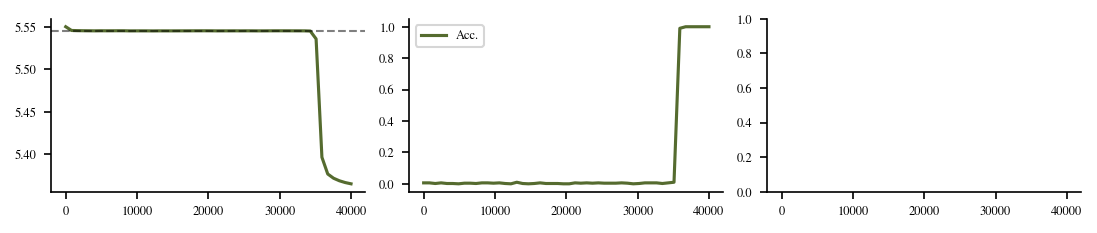

In [122]:
fig , axes = create_fig(ncols=3,size='double',h=0.2)
ax = axes[0]
ax.plot(metrics['step'],metrics['loss'],label='Loss',color='darkolivegreen',lw=1.5)
ax.axhline(np.log(V),ls='--',color='black',alpha=0.5,label=r'$\log V$')

ax = axes[1]
ax.plot(metrics['step'],metrics['top1_accuracy'],label='Acc.',color='darkolivegreen',lw=1.5)

# ax = axes[2]
# ax.plot(new_metrics['step'],new_metrics['M'],label=r'$M^{on}$',color='k',lw=1.5)
# ax.plot(new_metrics['step'],new_metrics['Q'],label=r'$Q^{on}$',color='goldenrod',lw=1.5)
# ax.plot(new_metrics['step'],new_metrics['G'],label=r'$\Gamma^{on}$',color='darkolivegreen',lw=1.5)
ax.legend()

In [10]:
# Constants
L = 512
V = 128
rho = 0.2
K = int(rho*V)
beta = 0.5
eta_0 = 1536

lmbda = L/((1+rho)*V)
A = beta * (rho / (1+rho))
B = 0.5*beta*eta_0*(rho/(1+rho))**2


# Initial values
M0 , Q0 , G0 = 1/np.sqrt(L), 1/np.sqrt(K), 1/np.sqrt(V-K)
q0 = np.array([M0, Q0, G0])

# Integrate ODE
ode_times = np.linspace(0, 10000, 100)
solution = odeint(gradient, q0, ode_times, args=(lmbda, A, V, K, L, B))

print(f'ODE solution shape: {solution.shape}')

ODE solution shape: (100, 3)


In [ ]:
#  480651 cerazova  20   0  220772   3488   3148 S   0.0   0.0   0:00.00 bash shell/submit.sh                                
#  480903 cerazova  20   0  220772   3424   3060 S   0.0   0.0   0:00.00 bash shell/monitor.sh     

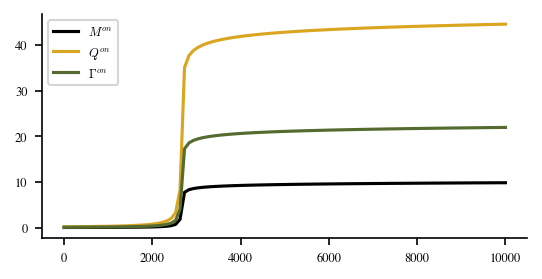

In [11]:
fig , axes = create_fig()

display_times = ode_times #/ np.sqrt(bs)

Mth, Qth, Gth = solution[:,0], solution[:,1], solution[:,2]

ax = axes
ax.plot(display_times, Mth, label=r'$M^{on}$', color='k', lw=1.5)
ax.plot(display_times, Qth, label=r'$Q^{on}$', color='goldenrod', lw=1.5)
ax.plot(display_times, Gth, label=r'$\Gamma^{on}$', color='darkolivegreen', lw=1.5)

ax.legend()

Figure saved on /u/c/cerazova/InContextLearning/Manuscript/figures as ode_solution.png


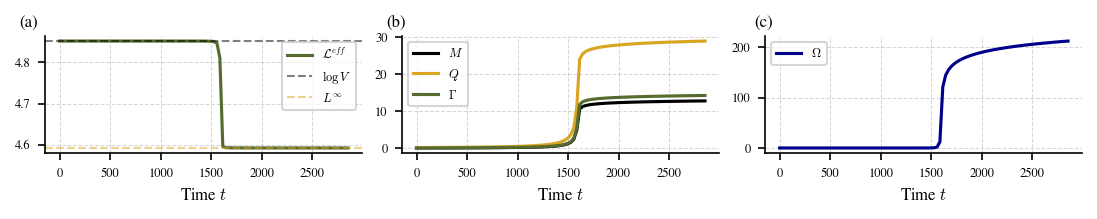

In [115]:
fig , axes = create_fig(ncols=3,size='double',h=0.17)

display_times = ode_times #/ np.sqrt(bs)

Mth, Qth, Gth = solution[:,0], solution[:,1], solution[:,2]
Omega_th = Mth*Qth*Gth/K
L_th = np.array([quad(integrand, 0, 1, args=(m, A, V, om))[0] for om in Omega_th])
L_th = L_th * rho/(1+rho) + np.log(V) * (1-av_Pind)

ax = axes[0]
ax.plot(display_times, L_th, label=r'$\mathcal{L}^{eff}$', color='darkolivegreen', lw=1.5)
ax.axhline(np.log(V), ls='--', color='black', alpha=0.5, label=r'$\log V$') 
ax.axhline(np.log(V) * (1-av_Pind), ls='--', color='goldenrod', alpha=0.5, label=r'$L^\infty$')
ax.set_xlabel(r'Time $t$', fontsize=8)
# ax.set_title(r'$\mathcal{L}^{eff}$', fontsize=8)
ax.grid(lw=0.5, ls='--', alpha=0.5)
ax.legend()

ax = axes[1]
ax.plot(display_times, Mth, label=r'$M$', color='k', lw=1.5)
ax.plot(display_times, Qth, label=r'$Q$', color='goldenrod', lw=1.5)
ax.plot(display_times, Gth, label=r'$\Gamma$', color='darkolivegreen', lw=1.5)
ax.set_xlabel(r'Time $t$', fontsize=8)
# ax.set_title(r'Order Parameters', fontsize=8)
# ax.set_title(r'ODE Solution for Order Parameters')
ax.grid(lw=0.5, ls='--', alpha=0.5)
ax.legend()

ax = axes[2]
ax.plot(display_times, Omega_th, label=r'$\Omega$', color='darkblue', lw=1.5)
ax.set_xlabel(r'Time $t$', fontsize=8)
# ax.set_title(r'Order Parameters', fontsize=8)
ax.grid(lw=0.5, ls='--', alpha=0.5)
ax.legend()

# ax.plot(display_times, solution[:,0]*solution[:,1]*solution[:,2]/K, label=r'$\Omega$', color='darkblue', lw=1.5)

# ax.set_yscale('log')
for i , tx in enumerate(['(a)','(b)','(c)']):
    fig.text(0.01+i*0.34,1,tx,fontsize=8)

save_fig(fig,'ode_solution',base_dir='../../Manuscript/figures')

# Extras

In [96]:
def L(h_star,V,sigma=1.0,n_samples=5000):
    hs = np.random.randn(V-1,n_samples)*sigma
    e_hs = np.exp(hs).sum(axis=0)
    e_h_star = np.exp(h_star)
    loss = -np.log(e_h_star/(e_h_star+e_hs))
    return loss.mean()


def L_vectorized(h_star_values, V_values, sigma_star=1.0,sigma=1.0, n_samples=5000):
    h_star_values = np.asarray(h_star_values, dtype=float)
    V_values = np.asarray(V_values, dtype=int)

    max_V = V_values.max()
    hs = np.random.randn(max_V - 1, n_samples) * sigma
    exp_hs = np.exp(hs)  # shape: (max_V - 1, n_samples)

    # For each V, keep only the first (V-1) terms
    col_idx = np.arange(max_V - 1)[None, :]         # (1, max_V - 1)
    valid = col_idx < (V_values[:, None] - 1)        # (len(V_values), max_V - 1)
    e_hs = np.where(valid[:, :, None], exp_hs[None, :, :], 0.0).sum(axis=1)
    # shape: (len(V_values), n_samples)

    star_noise = np.random.randn(len(h_star_values), n_samples) * sigma_star
    h_star_values = h_star_values[:, None] + star_noise  # shape: (len(h_star_values), n_samples)
    e_h_star = np.exp(h_star_values)[:, None,:]
    # e_h_star = np.exp(h_star_values )[:, None, None]      # (len(h_star_values), 1, 1)
    denom = e_h_star + e_hs[None, :, :]                  # (len(h_star_values), len(V_values), n_samples)
    prob = e_h_star / denom

    losses = -np.log(prob).mean(axis=2)                  # (len(h_star_values), len(V_values))
    return losses

In [97]:
h_star_values = np.linspace(-2,6,50)
V_values = np.arange(50,500,3)

losses = L_vectorized(h_star_values, V_values,sigma=1.0, n_samples=5000)
print(losses.shape)  # Should be (len(h_star_values), len(V_values))

(50, 150)


Text(0, 0.5, '$h^*$')

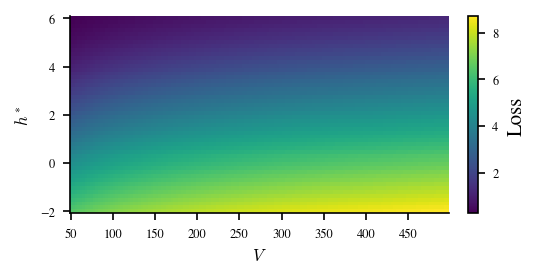

In [98]:
fig , axes = create_fig()

ax = axes

im = ax.pcolormesh(V_values, h_star_values, losses)
plt.colorbar(im, ax=ax, label='Loss')
ax.set_xlabel(r'$V$',fontsize=8)
ax.set_ylabel(r'$h^*$',fontsize=8)


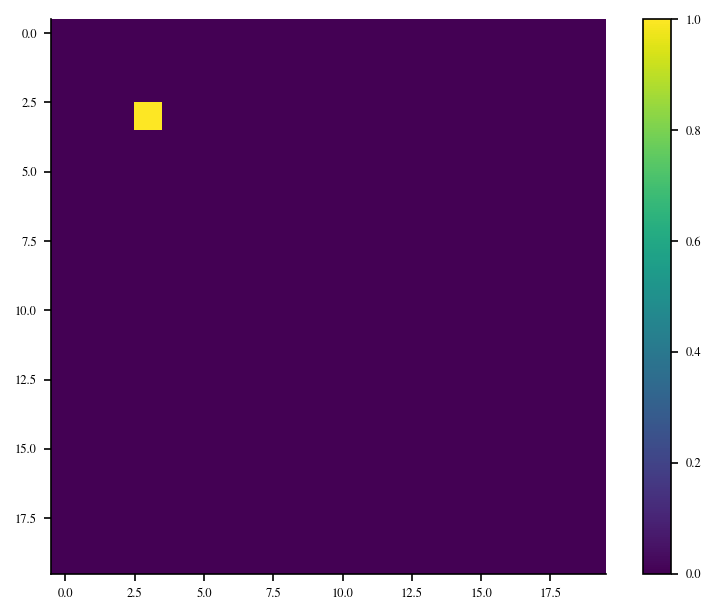

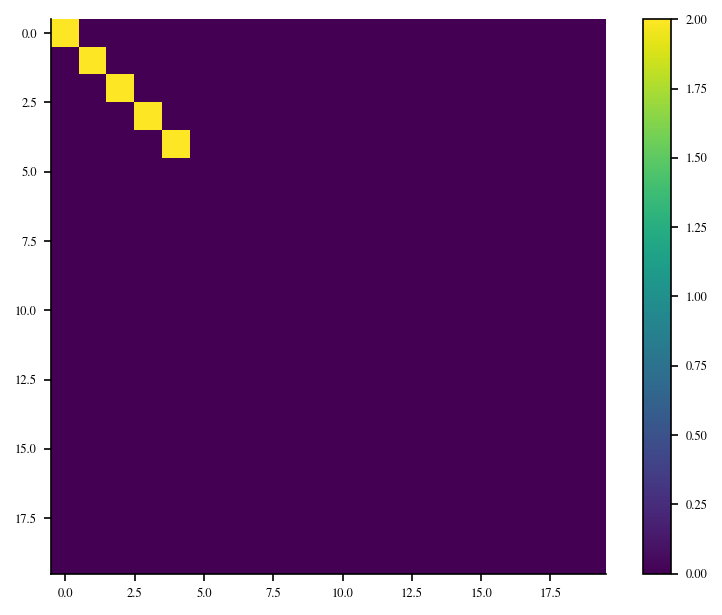

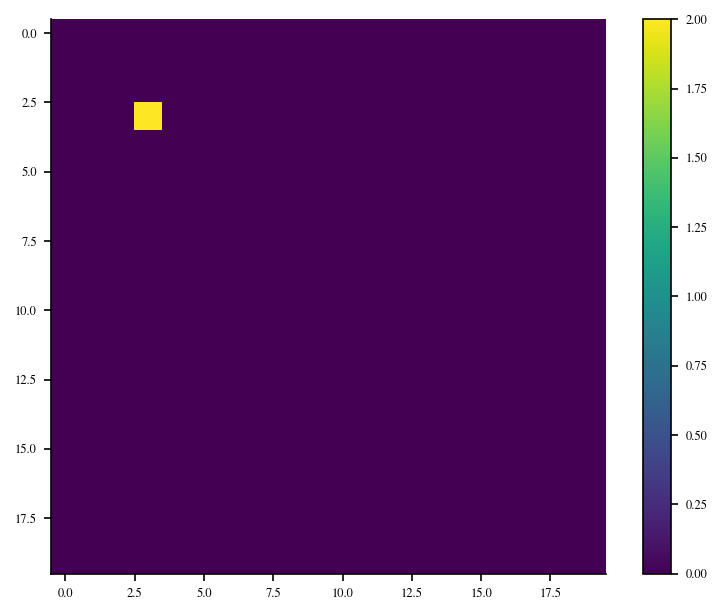

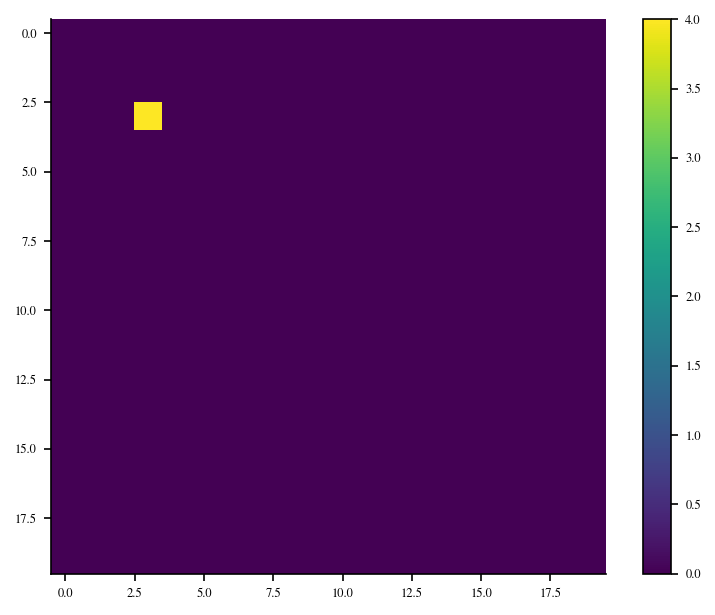

In [153]:
V = 20
K = 5
A = np.zeros((V,V))
B = np.zeros((V,V))
for i in np.arange(K):
    B[i,i] = 2

A[3,3] = 1.0
plt.imshow(A)
plt.colorbar()
plt.show()
plt.imshow(B)
plt.colorbar()
plt.show()
plt.imshow(A@B)
plt.colorbar()
plt.show()
plt.imshow(B.T@A@B)
plt.colorbar()

In [170]:
reader = ExperimentReader('results','../data')
run_id = reader.list_runs()[-1]

cfg = reader.load_config(run_id)
metrics = reader.load_metrics(run_id)
metrics = metrics.pivot(index='step', columns='metric', values='value').reset_index()
print(metrics.head())
list_hst = reader.list_artifacts(run_id,'histograms')
idx = 0
# hst = reader.load_artifact(run_id,list_hst.iloc[idx]['file'],'histograms')
# print(hst.keys())

list_mtx = reader.list_artifacts(run_id,'matrices')
list_mtx

metric  step      loss  top1_accuracy
0          0  5.015302       0.005039
1         20  5.011751       0.004031
2         40  5.011218       0.008398
3         61  5.011004       0.005375
4         81  5.010900       0.005375


,step,name,file,type
0,0,M,M_step_0.npy,tensor
1,0,Q,Q_step_0.npy,tensor
2,0,G,G_step_0.npy,tensor
3,20,M,M_step_20.npy,tensor
4,20,Q,Q_step_20.npy,tensor
...,...,...,...,...
145,978,Q,Q_step_978.npy,tensor
146,978,G,G_step_978.npy,tensor
147,999,M,M_step_999.npy,tensor
148,999,Q,Q_step_999.npy,tensor


In [5]:
from scipy.stats import norm
g = norm.pdf
# norm.

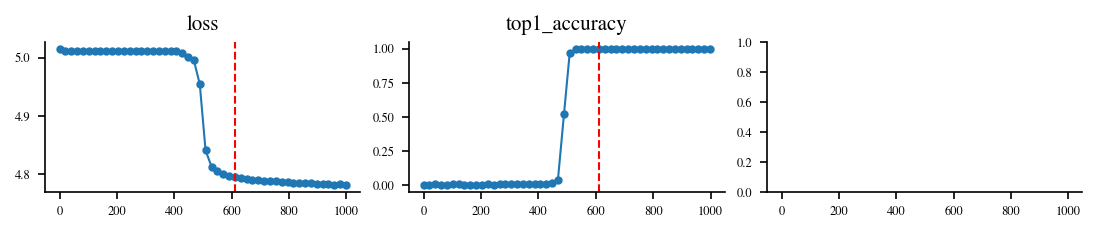

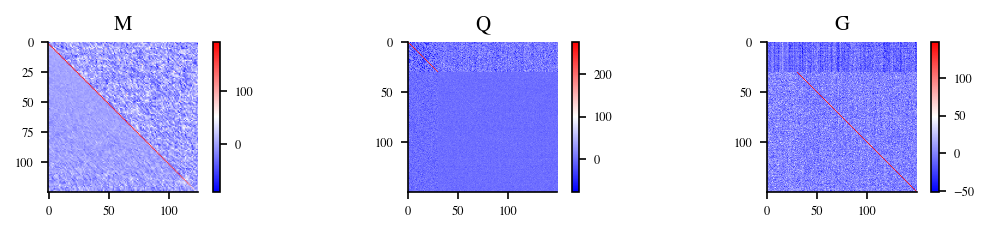

In [172]:
idx = 30

fig , axes = create_fig(nrows=1,ncols=3,size='double',h=0.2)

for i,name in enumerate(['loss','top1_accuracy']):
    axes[i].plot(metrics['step'],metrics[name],marker='.')
    axes[i].set_title(name)
    axes[i].axvline(x=metrics['step'].iloc[idx],color='red',linestyle='--',label='checkpoint')

# fig , axes = create_fig(nrows=1,ncols=1)
# hst = reader.load_artifact(run_id,list_hst.iloc[idx]['file'],'histograms')
# edges = hst['edges']
# dx = edges[1]-edges[0]
# vmin , vmax = hst['range']
# x = np.linspace(vmin,vmax,100)
# for i , (kw ,color) in enumerate(zip(['on','off'],['red','blue'])):
#     axes.bar(edges[:-1], hst[f'{kw}_hist'],width=dx,align='edge',color=color,alpha=0.5,edgecolor='black')
#     axes.plot(x,g(x,loc=hst[f'{kw}_mean'],scale=hst[f'{kw}_std']),color=color,linestyle='-')


fig , axes = create_fig(ncols=3,size='double',h=0.2,sharex=False)

name = lambda x : f"{x}_step_{metrics['step'].iloc[idx]}.npy"

for i , kw in enumerate(['M','Q','G']):
    mtx = reader.load_artifact(run_id,name(kw),'matrices')
    im = axes[i].imshow(mtx[:300,:300],cmap='bwr')
    # im = axes[i].imshow(mtx,cmap='bwr')
    plt.colorbar(im,ax=axes[i])
    axes[i].set_title(kw)

In [173]:
M = reader.load_artifact(run_id,name("M"),'matrices')
Q = reader.load_artifact(run_id,name("Q"),'matrices')
G = reader.load_artifact(run_id,name("G"),'matrices')

print(name('M'))

#mask to select the diagonal i , i-1 
mask_M_on = np.zeros_like(M)
mask_M_off = np.zeros_like(M)
for i in range(1,M.shape[0]):
    mask_M_on[i,i-1] = 1
    mask_M_off[i,:i-1] = 1
mask_M_off = mask_M_off.astype(bool)
mask_M_on = mask_M_on.astype(bool)

M_on = M[mask_M_on]
M_off = M[mask_M_off]

mask_Q_on = np.zeros_like(Q)
mask_G_on = np.zeros_like(G)
for i in range(cfg['model_args']['vocab_size']):
    if i < cfg['data_args']['K']:
        mask_Q_on[i,i] = 1
    else:
        mask_G_on[i,i] = 1

mask_Q_on = mask_Q_on.astype(bool)
mask_G_on = mask_G_on.astype(bool)

Q_on = Q[mask_Q_on]
Q_off = Q[~mask_Q_on]

G_on = G[mask_G_on]
G_off = G[~mask_G_on]



M_step_611.npy


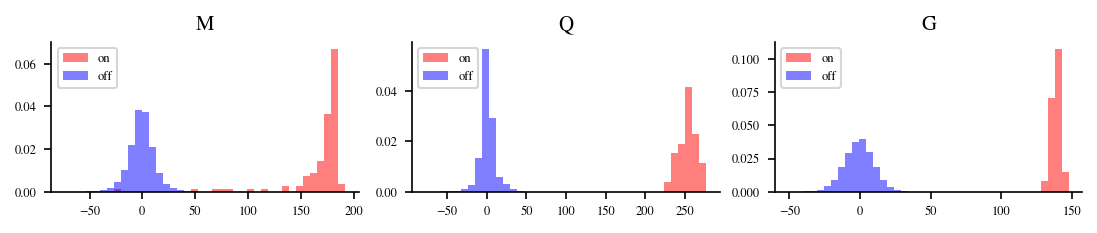

In [174]:
fig , axes = create_fig(nrows=1,ncols=3,size='double',h=0.2,sharex=False)

for i , (Xon,Xoff) in enumerate(zip([M_on,Q_on,G_on],[M_off,Q_off,G_off])):
    vmin = min(Xon.min(),Xoff.min())
    vmax = max(Xon.max(),Xoff.max())
    axes[i].hist(Xon,bins=40,alpha=0.5,color='red',label='on',density=True,range=(vmin,vmax))
    axes[i].hist(Xoff,bins=40,alpha=0.5,color='blue',label='off',density=True,range=(vmin,vmax))
    axes[i].set_title(['M','Q','G'][i])
    axes[i].legend()

In [155]:
def f(mu,rho):
    nus = np.arange(1,mu)
    return (1 - (-rho)**(mu-nus)).sum() 
    
def f_mean_real(L,rho):
    return (1/L) * (0.5*L*(L-1) + (rho/(rho+1)**2) * ( (-rho)**L + L*rho + L-1))

def f_mean_apx(L,rho):
    return 0.5*L
L = 20
rho = 0.1
f_vals = np.array([f(mu,rho) for mu in range(1,L+1) ])

print(f'Mean = {f_vals.mean():.4f}')
print(f'Mean real = {f_mean_real(L,rho):.4f}')
print(f'Mean apx = {f_mean_apx(L,rho):.4f}')


Mean = 9.5868
Mean real = 9.5868
Mean apx = 10.0000


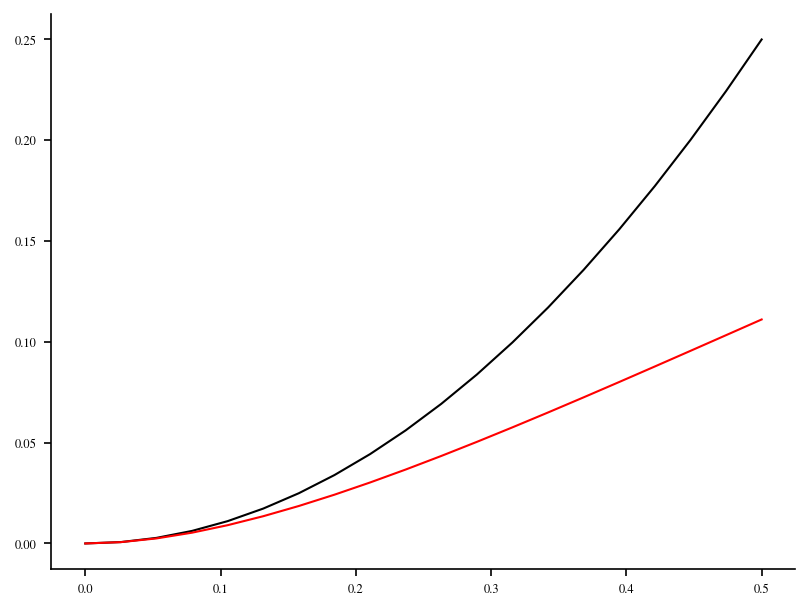

In [156]:
rhos = np.linspace(0,0.5,20)

plt.plot(rhos,rhos**2,color='black')
plt.plot(rhos,rhos**2/(1+rhos)**2,color='red')

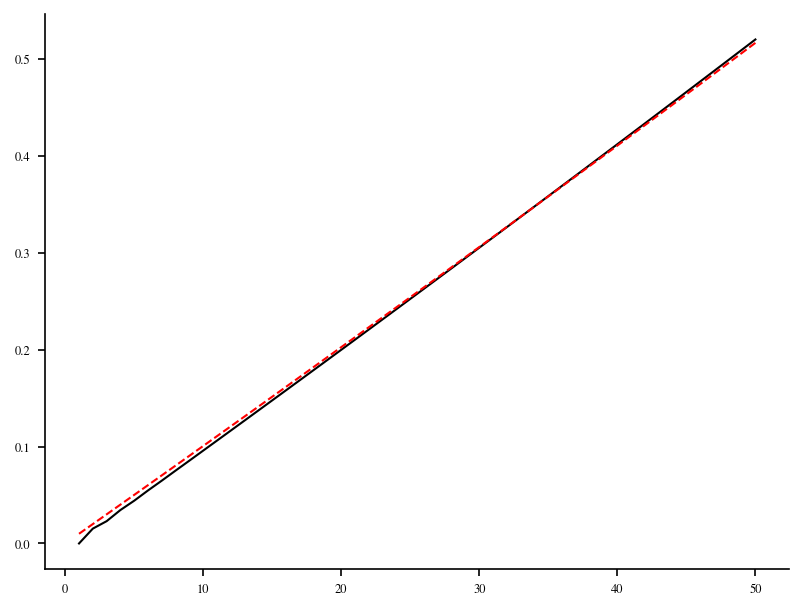

In [102]:
def theory(mu,rho,V):
    return 1 + np.exp(-mu/(V*(1+rho)))

def f(mu,rho,L,V):
    num = ((mu-1) + (rho + (-rho)**(mu))/(1+rho))/(L-1)
    den = theory(mu,rho,V)
    return num/den

rho = 0.5
L = 50
V = 500
mu = np.arange(1,L+1)
fval = f(mu,rho,L,V)

plt.plot(mu,fval,color='black')
plt.plot(mu,(mu/L)/theory(mu,rho,V),color='red',linestyle='--')
# plt.plot(mu,mu-1 + rho/(1+rho),color='blue',linestyle='--'  )